# Deep SARSA – Snake Game Training
This notebook trains a Deep SARSA agent on the Snake environment and visualizes:
- Score per Episode  
- Total Reward per Episode  
- Epsilon Decay Curve


In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import importlib, snake_deep_sarsa
importlib.reload(snake_deep_sarsa)
from snake_deep_sarsa import SnakeGame, SARSAAgent, train_agent_sarsa, GRID_SIZE

In [27]:
env = SnakeGame(grid_size=GRID_SIZE)
agent = SARSAAgent()

In [28]:
episodes = 25000  # same as your DQN example

scores, rewards, epsilons, losses = train_agent_sarsa(env, agent, episodes)

Training Deep SARSA for 25000 episodes...
Episode 100/25000 | Score: 0 | Avg(100): 0.11 | Best: 2 | ε: 0.980 | Avg Loss: 1.5781
Episode 200/25000 | Score: 0 | Avg(100): 0.18 | Best: 2 | ε: 0.961 | Avg Loss: 2.3487
Episode 300/25000 | Score: 0 | Avg(100): 0.27 | Best: 2 | ε: 0.942 | Avg Loss: 2.0772
Episode 400/25000 | Score: 0 | Avg(100): 0.29 | Best: 2 | ε: 0.923 | Avg Loss: 2.1420
Episode 500/25000 | Score: 0 | Avg(100): 0.23 | Best: 2 | ε: 0.905 | Avg Loss: 3.2041
Episode 600/25000 | Score: 0 | Avg(100): 0.30 | Best: 2 | ε: 0.887 | Avg Loss: 2.4681
Episode 700/25000 | Score: 1 | Avg(100): 0.25 | Best: 2 | ε: 0.869 | Avg Loss: 3.1335
Episode 800/25000 | Score: 0 | Avg(100): 0.39 | Best: 2 | ε: 0.852 | Avg Loss: 2.8879
Episode 900/25000 | Score: 0 | Avg(100): 0.39 | Best: 2 | ε: 0.835 | Avg Loss: 3.1803
Episode 1000/25000 | Score: 0 | Avg(100): 0.42 | Best: 3 | ε: 0.819 | Avg Loss: 3.7351
Episode 1100/25000 | Score: 0 | Avg(100): 0.47 | Best: 4 | ε: 0.803 | Avg Loss: 4.7303
Episode 12

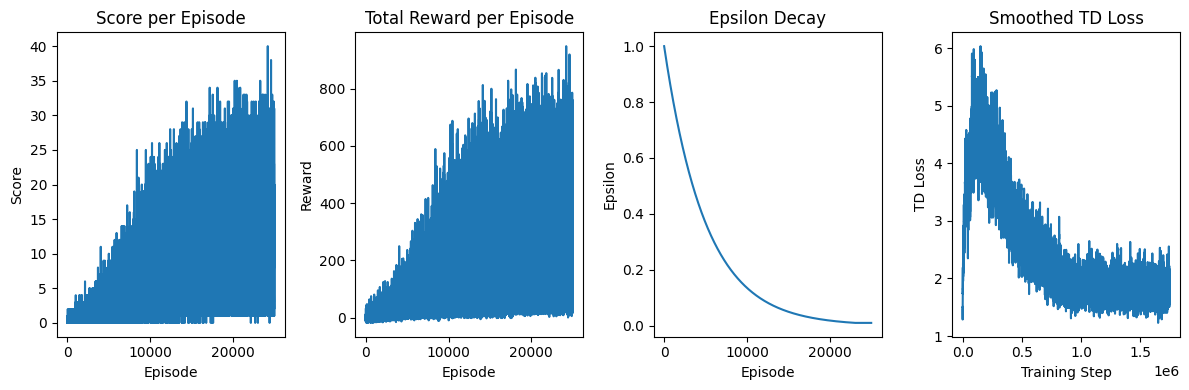


Training complete! Best score: 40
Final 100-episode average: 14.38


In [43]:
def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.plot(scores)
plt.title('Score per Episode')
plt.xlabel('Episode')
plt.ylabel('Score')

plt.subplot(1, 4, 2)
plt.plot(rewards)
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Reward')

plt.subplot(1, 4, 3)
plt.plot(epsilons)
plt.title('Epsilon Decay')
plt.xlabel('Episode')
plt.ylabel('Epsilon')

plt.subplot(1, 4, 4)
plt.plot(moving_average(losses, 500))
plt.title('Smoothed TD Loss')
plt.xlabel('Training Step')
plt.ylabel('TD Loss')

plt.tight_layout()
plt.show()

print(f"\nTraining complete! Best score: {max(scores)}")
print(f"Final 100-episode average: {np.mean(scores[-100:]):.2f}")
